# Project data exploration - looking at relplot and scatter
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name: DGIM  
Created by Grant Biellak 017135261  
Last updated: March 22nd  
This dataset covers buy now pay later transactions in Nigeria.

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

### Q1: Show the number of missing data in each column of the dataframe

In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset
import pandas as pd
dataset = load_dataset("electricsheepafrica/nigerian-banking-bnpl")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

nigerian_bnpl_full.parquet:   0%|          | 0.00/74.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000000 [00:00<?, ? examples/s]

In [3]:
df = dataset["train"].to_pandas()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   transaction_id         object        
 1   purchase_date          datetime64[ns]
 2   customer_id            object        
 3   merchant_category      object        
 4   merchant_name          object        
 5   customer_state         object        
 6   principal_ngn          float64       
 7   interest_rate_monthly  float64       
 8   tenor_days             int64         
 9   num_installments       int64         
 10  provider               object        
 11  credit_score           int64         
 12  first_time_customer    bool          
 13  first_payment_due      datetime64[ns]
 14  default_30d            bool          
 15  default_90d            bool          
dtypes: bool(3), datetime64[ns](2), float64(2), int64(3), object(6)
memory usage: 204.1+ MB


### Q2: Show the data type for each column of the dataframe

In [4]:
# Your code here . . .
df.dtypes

,0
transaction_id,object
purchase_date,datetime64[ns]
customer_id,object
merchant_category,object
merchant_name,object
customer_state,object
principal_ngn,float64
interest_rate_monthly,float64
tenor_days,int64
num_installments,int64


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

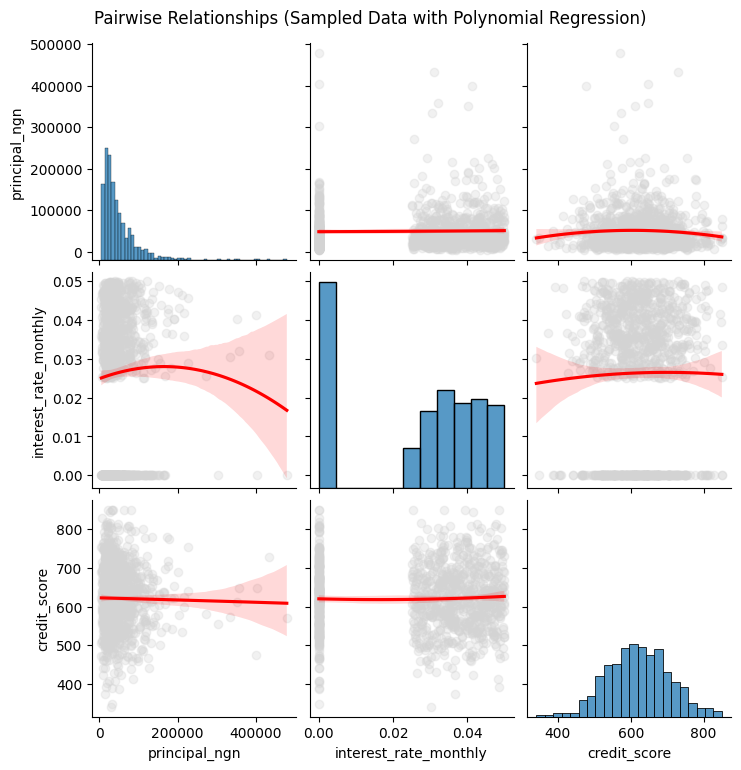

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    "principal_ngn",
    "interest_rate_monthly",
    "credit_score"
]
df_sample = df[cols].sample(1000)

sns.pairplot(
    df_sample,
    kind="reg",
    plot_kws={
        "scatter_kws": {"color": "lightgray", "alpha": 0.3},
        "line_kws": {"color": "red"},
        "order": 2
    }
)

plt.suptitle("Pairwise Relationships (Sampled Data with Polynomial Regression)", y=1.02)
plt.show()

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

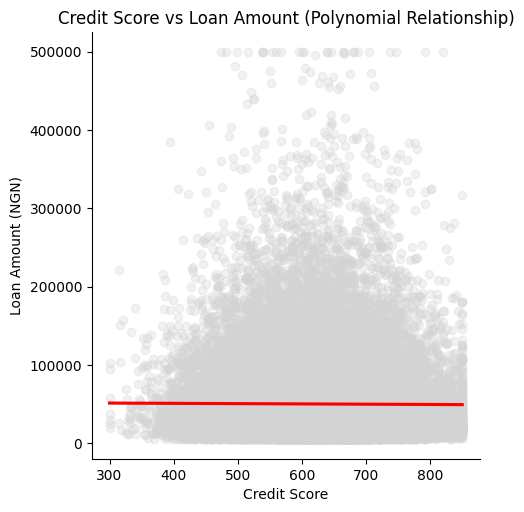

In [12]:
# Your code here . . .
sns.lmplot(
    data=df.head(50000),
    x="credit_score",
    y="principal_ngn",
    scatter_kws={"color": "lightgray", "alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Credit Score vs Loan Amount (Polynomial Relationship)")
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount (NGN)")

plt.show()

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

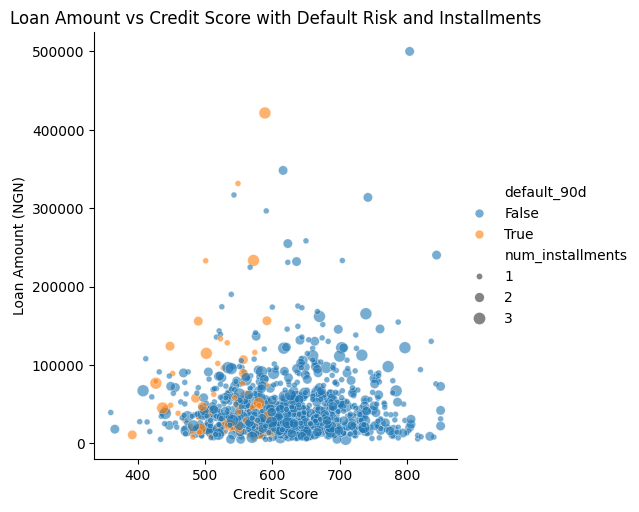

In [10]:
# Your code here . . .
df_sample = df.sample(1000)

sns.relplot(
    data=df_sample,
    x="credit_score",
    y="principal_ngn",
    hue="default_90d",          # highlight risk (default or not)
    size="num_installments",    # show loan structure
    alpha=0.6
)

plt.title("Loan Amount vs Credit Score with Default Risk and Installments")
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount (NGN)")
plt.show()

### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

In [ ]:
# Your code here . . .